# Heart Disease Risk Prediction
**Dataset:** UCI Heart Disease (Cleveland subset)  
**Goal:** Predict presence of heart disease and explain risk factors using SHAP

## 1. Imports

In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from scipy.stats import loguniform

import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Data Loading & Exploration

In [228]:
df_raw = pd.read_csv('heart_disease_uci.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [229]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


In [230]:
df_raw.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


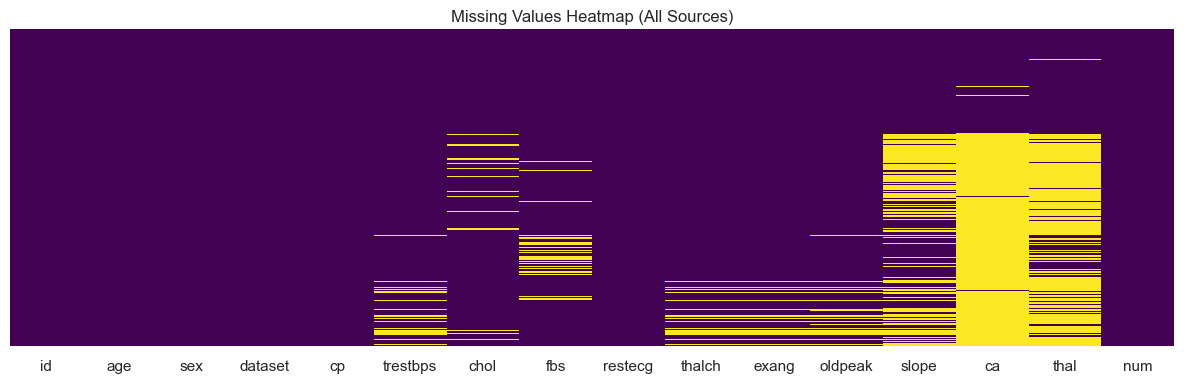

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [231]:
# Missing value heatmap (full dataset before filtering)
plt.figure(figsize=(12, 4))
sns.heatmap(df_raw.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (All Sources)')
plt.tight_layout()
plt.show()

print('Missing values per column:')
print(df_raw.isnull().sum())

In [232]:
print('Rows per source:')
print(df_raw['dataset'].value_counts())

Rows per source:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64


## 3. Cleaning & Preprocessing

> **Why Cleveland only?**  
> The Hungary, Switzerland, and VA Long Beach subsets have heavy missingness in `ca`, `thal`, and `slope`. The Cleveland subset (~303 rows) is complete, the most studied, and the gold standard for this dataset.

In [233]:
# Filter to Cleveland and drop administrative columns
df = df_raw[df_raw['dataset'] == 'Cleveland'].copy()
df = df.drop(columns=['id', 'dataset'])
print(f'Cleveland rows before dropna: {len(df)}')
print(f'Missing values:\n{df.isnull().sum()}')

Cleveland rows before dropna: 304
Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       1
ca          5
thal        3
num         0
dtype: int64


In [234]:
# Drop remaining rows with any missing values
df = df.dropna()
print(f'Rows after dropna: {len(df)}')

Rows after dropna: 297


In [235]:
# Binarize target: 0 = no disease, 1 = disease (num 1-4)
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])
print('Target distribution:')
print(df['target'].value_counts())
print(f'Disease prevalence: {df["target"].mean():.1%}')

Target distribution:
target
0    160
1    137
Name: count, dtype: int64
Disease prevalence: 46.1%


In [236]:
# Create age group feature using medical health brackets
age_bins   = [0, 29, 44, 59, 120]
age_labels = ['Young Adult (18-29)', 'Adult (30-44)', 'Middle-Aged (45-59)', 'Senior (60+)']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
print('Age group distribution:')
print(df['age_group'].value_counts().sort_index())

Age group distribution:
age_group
Young Adult (18-29)      1
Adult (30-44)           52
Middle-Aged (45-59)    153
Senior (60+)            91
Name: count, dtype: int64


In [237]:
# One-hot encode all categorical columns including age_group
# ca is ordinal numeric (0-3), kept as-is
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'age_group']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df_encoded = df_encoded.reset_index(drop=True)
print(f'Shape after OHE: {df_encoded.shape}')
print('Columns:', df_encoded.columns.tolist())

Shape after OHE: (297, 22)
Columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'age_group_Adult (30-44)', 'age_group_Middle-Aged (45-59)', 'age_group_Senior (60+)']


In [238]:
# Separate features and target
X = df_encoded.drop(columns=['target']).reset_index(drop=True).copy()
y = df_encoded['target'].reset_index(drop=True).copy()
feature_cols = X.columns.tolist()
print(f'Features ({len(feature_cols)}): {feature_cols}')

Features (21): ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect', 'age_group_Adult (30-44)', 'age_group_Middle-Aged (45-59)', 'age_group_Senior (60+)']


In [239]:
# Scale numeric features â€” operate on numpy to avoid pandas version issues
numeric_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
scaler = StandardScaler()

numeric_idx = [X.columns.get_loc(c) for c in numeric_cols]
X_array = X.values.astype(float)
X_array[:, numeric_idx] = scaler.fit_transform(X_array[:, numeric_idx])
X = pd.DataFrame(X_array, columns=feature_cols)

# Save preprocessing artifacts for dashboard
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print('Saved: scaler.pkl, feature_cols.pkl')

Saved: scaler.pkl, feature_cols.pkl


## 4. Exploratory Data Analysis

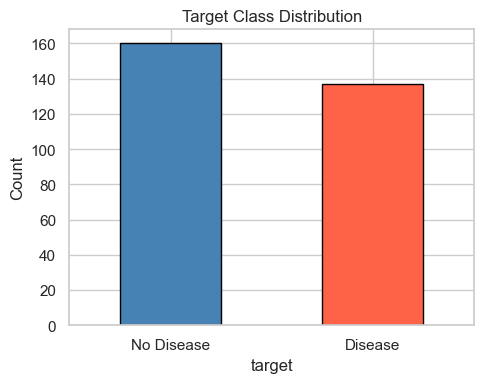

In [240]:
# Class distribution
fig, ax = plt.subplots(figsize=(5, 4))
df['target'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(['No Disease', 'Disease'], rotation=0)
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

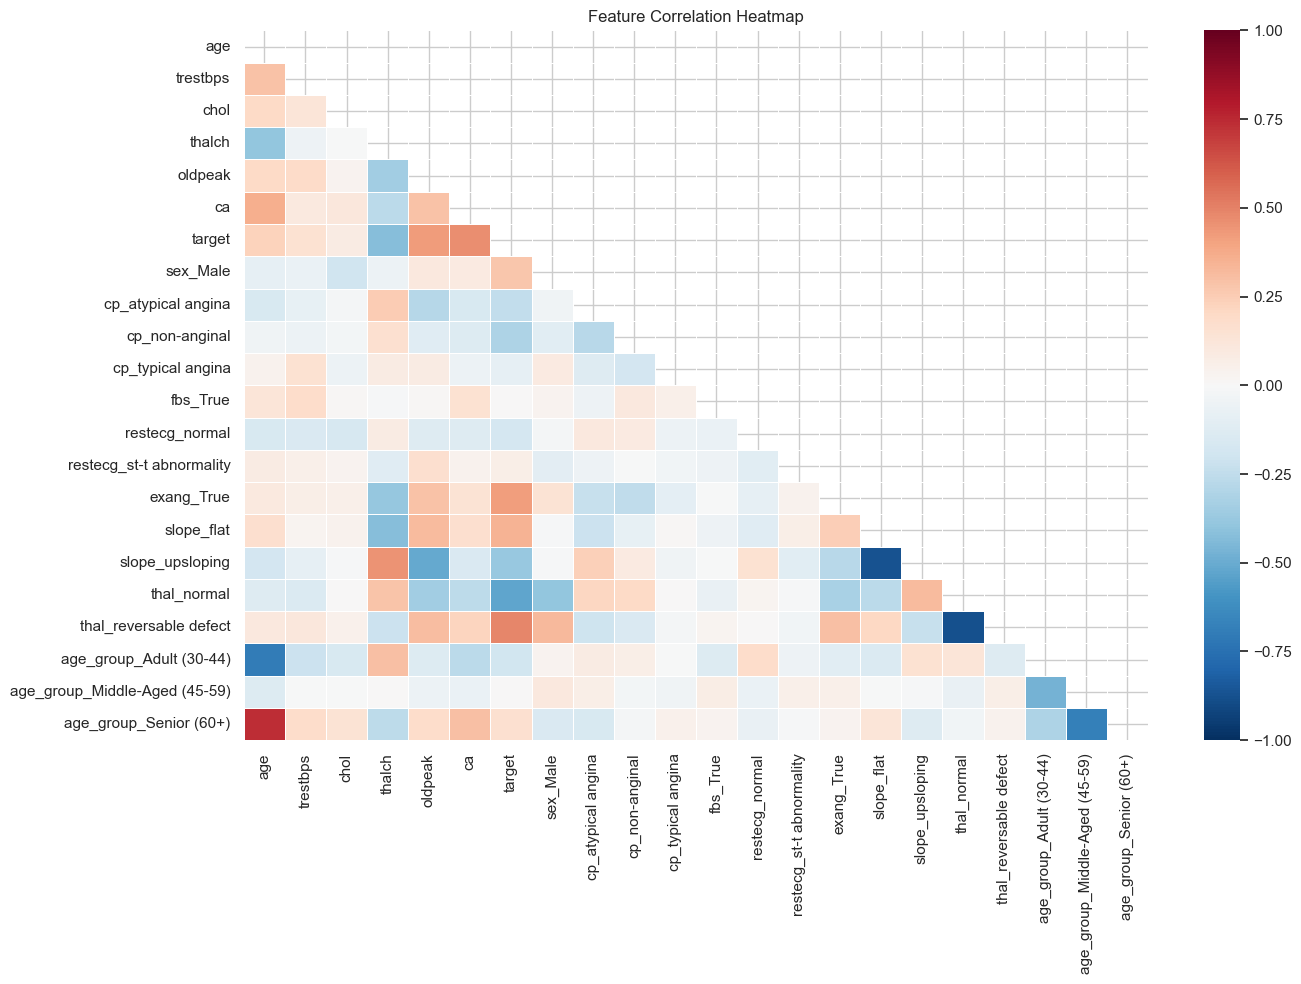

In [241]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdBu_r', center=0, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

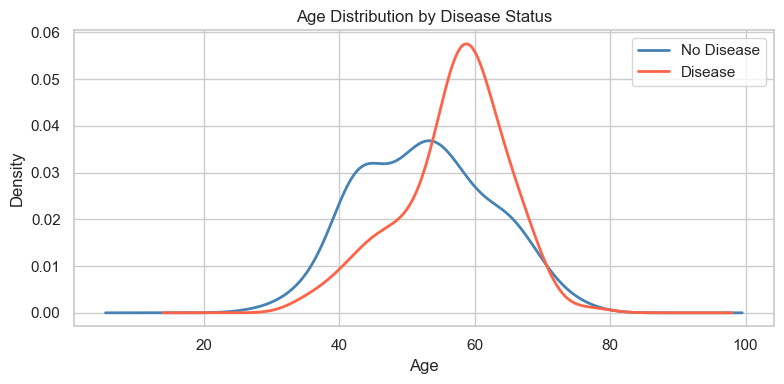

In [242]:
# Age distribution by disease status
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    subset = df[df['target'] == label]['age']
    subset.plot(kind='kde', ax=ax, label=['No Disease', 'Disease'][label], color=color, linewidth=2)
ax.set_xlabel('Age')
ax.set_title('Age Distribution by Disease Status')
ax.legend()
plt.tight_layout()
plt.show()

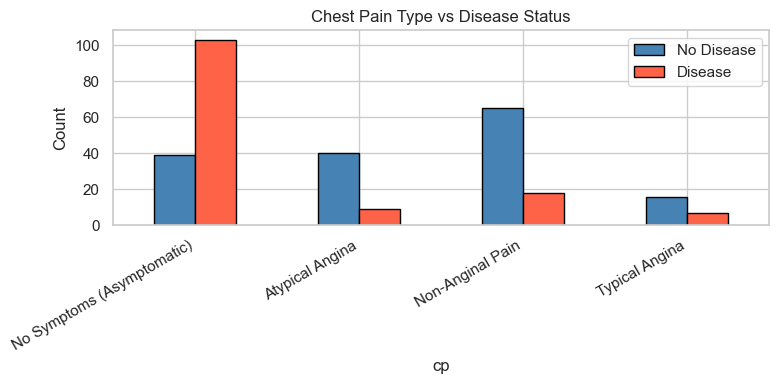

In [243]:
# Chest pain type vs disease status
fig, ax = plt.subplots(figsize=(8, 4))
cp_counts = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')

cp_label_map = {
    'typical angina':    'Typical Angina',
    'atypical angina':   'Atypical Angina',
    'non-anginal':       'Non-Anginal Pain',
    'asymptomatic':      'No Symptoms (Asymptomatic)',
}
ax.set_xticklabels(
    [cp_label_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    rotation=30, ha='right'
)
ax.set_title('Chest Pain Type vs Disease Status')
ax.set_ylabel('Count')
ax.legend(['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

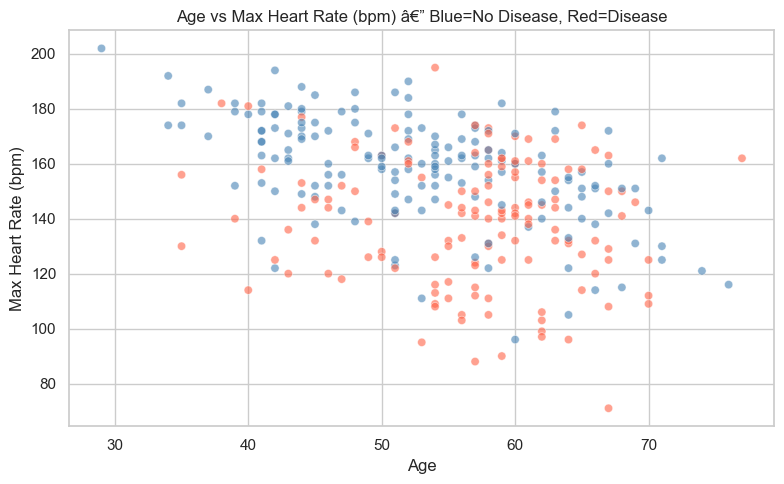

In [244]:
# Max heart rate vs Age scatter, colored by disease
fig, ax = plt.subplots(figsize=(8, 5))
c = df['target'].map({0: 'steelblue', 1: 'tomato'})
ax.scatter(df['age'], df['thalch'], c=c, alpha=0.6, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Age')
ax.set_ylabel('Max Heart Rate (bpm)')
ax.set_title('Age vs Max Heart Rate (bpm) â€” Blue=No Disease, Red=Disease')
plt.tight_layout()
plt.show()

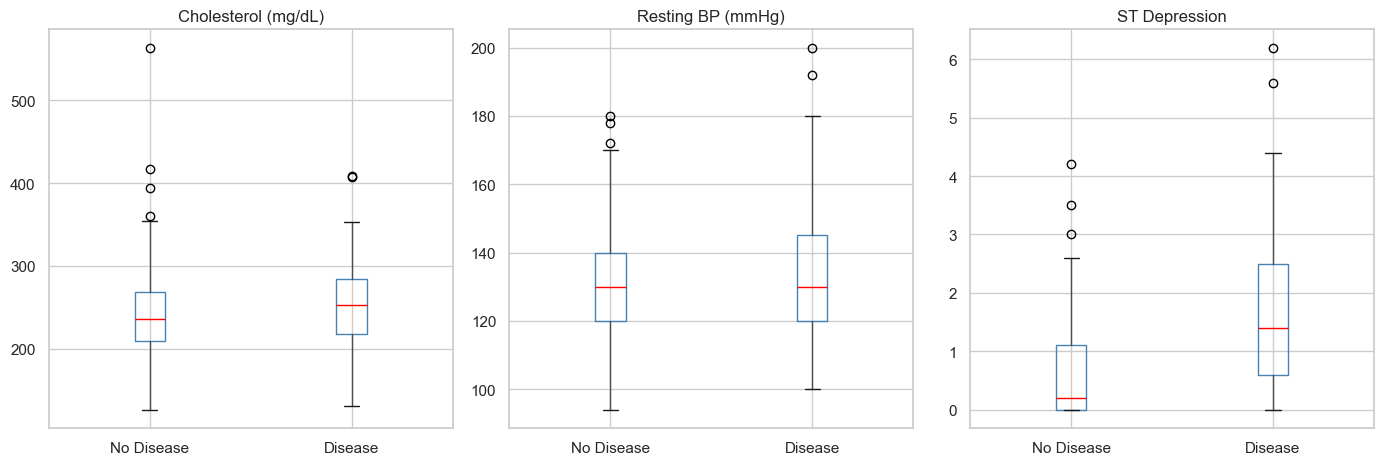

In [245]:
# Boxplots: key numeric features by disease status
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col, title in zip(axes, ['chol', 'trestbps', 'oldpeak'],
                          ['Cholesterol (mg/dL)', 'Resting BP (mmHg)', 'ST Depression']):
    df.boxplot(column=col, by='target', ax=ax,
               boxprops=dict(color='steelblue'), medianprops=dict(color='red'))
    ax.set_title(title)
    ax.set_xlabel('')
    ax.set_xticklabels(['No Disease', 'Disease'])
plt.suptitle('')
plt.tight_layout()
plt.show()

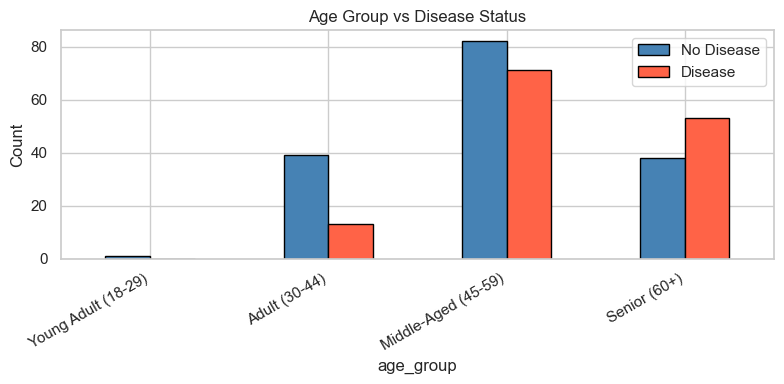

In [246]:
# Age group vs disease status
fig, ax = plt.subplots(figsize=(8, 4))
age_group_counts = df.groupby(['age_group', 'target']).size().unstack(fill_value=0)
age_group_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_title('Age Group vs Disease Status')
ax.set_ylabel('Count')
ax.legend(['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

In [247]:
# ---- Plain-speech label mapping (used in SHAP plots and dashboard) ----
FEATURE_LABEL_MAP = {
    'age':                           'Age',
    'trestbps':                      'Resting Blood Pressure (mmHg)',
    'chol':                          'Cholesterol (mg/dL)',
    'thalch':                        'Max Heart Rate (bpm)',
    'oldpeak':                       'ST Depression',
    'ca':                            'Major Vessels (Fluoroscopy)',
    'sex_Male':                      'Sex: Male',
    'cp_atypical angina':            'Chest Pain: Atypical Angina',
    'cp_non-anginal':                'Chest Pain: Non-Anginal Pain',
    'cp_typical angina':             'Chest Pain: Typical Angina',
    'fbs_True':                      'Fasting Blood Sugar > 120 mg/dL',
    'restecg_normal':                'Resting ECG: Normal',
    'restecg_st-t abnormality':      'Resting ECG: ST-T Wave Abnormality',
    'exang_True':                    'Exercise-Induced Angina: Yes',
    'slope_flat':                    'ST Slope: Flat',
    'slope_upsloping':               'ST Slope: Upsloping',
    'thal_normal':                   'Thalassemia: Normal',
    'thal_reversable defect':        'Thalassemia: Reversible Defect',
    'age_group_Adult (30-44)':       'Age Group: Adult (30â€“44)',
    'age_group_Middle-Aged (45-59)': 'Age Group: Middle-Aged (45â€“59)',
    'age_group_Senior (60+)':        'Age Group: Senior (60+)',
}

## 5. Model Training

In [248]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Train: 237 | Test: 60


In [249]:
# ---- Base models (untuned) â€” initial benchmark ----
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}

for name, mdl in base_models.items():
    mdl.fit(X_train, y_train)
    y_pred  = mdl.predict(X_test)
    y_proba = mdl.predict_proba(X_test)[:, 1]
    acc = (y_pred == y_test).mean()
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': mdl, 'acc': acc, 'auc': auc,
                     'y_pred': y_pred, 'y_proba': y_proba}
    print(f'\n=== {name} (base) ===')
    print(f'Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


=== Logistic Regression (base) ===
Accuracy: 0.8500 | ROC-AUC: 0.9520
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60


=== Random Forest (base) ===
Accuracy: 0.8500 | ROC-AUC: 0.9397
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60


=== Gradient Boosting (base) ===
Accuracy: 0.8667 | ROC-AUC: 0.9085
              precision    recall  f1-score   support

  No Disease       0.90      0.84      0.87        32
     Disease       0.83      0.8

In [250]:
# ---- Hyperparameter Tuning: RandomizedSearchCV (5-fold CV, scoring=roc_auc) ----
print("=" * 60)
print("HYPERPARAMETER TUNING")
print("=" * 60)

# --- Random Forest ---
rf_param_dist = {
    'n_estimators':      [50, 100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2', 0.5, 0.7],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1
)
rf_search.fit(X_train, y_train)

rf_best   = rf_search.best_estimator_
rf_proba  = rf_best.predict_proba(X_test)[:, 1]
rf_pred   = rf_best.predict(X_test)
rf_auc    = roc_auc_score(y_test, rf_proba)
rf_acc    = (rf_pred == y_test).mean()

print(f'\nBest RF params : {rf_search.best_params_}')
print(f'Tuned RF â€” Accuracy: {rf_acc:.4f} | ROC-AUC: {rf_auc:.4f}')
print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

# --- Logistic Regression ---
lr_param_dist = {
    'C':       loguniform(1e-3, 100),
    'solver':  ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
}
lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_distributions=lr_param_dist,
    n_iter=30, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42, verbose=1
)
lr_search.fit(X_train, y_train)

lr_best   = lr_search.best_estimator_
lr_proba  = lr_best.predict_proba(X_test)[:, 1]
lr_pred   = lr_best.predict(X_test)
lr_auc    = roc_auc_score(y_test, lr_proba)
lr_acc    = (lr_pred == y_test).mean()

print(f'\nBest LR params : {lr_search.best_params_}')
print(f'Tuned LR â€” Accuracy: {lr_acc:.4f} | ROC-AUC: {lr_auc:.4f}')
print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

# ---- Overwrite results dict with tuned models ----
results['Random Forest'].update({
    'model': rf_best, 'acc': rf_acc, 'auc': rf_auc,
    'y_pred': rf_pred, 'y_proba': rf_proba
})
results['Logistic Regression'].update({
    'model': lr_best, 'acc': lr_acc, 'auc': lr_auc,
    'y_pred': lr_pred, 'y_proba': lr_proba
})

print('\n--- Updated Model Comparison (Tuned) ---')
for name, res in results.items():
    print(f'  {name}: AUC={res["auc"]:.4f} | Accuracy={res["acc"]:.4f}')

HYPERPARAMETER TUNING
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best RF params : {'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': 10}
Tuned RF â€” Accuracy: 0.8500 | ROC-AUC: 0.9453
              precision    recall  f1-score   support

  No Disease       0.83      0.91      0.87        32
     Disease       0.88      0.79      0.83        28

    accuracy                           0.85        60
   macro avg       0.85      0.85      0.85        60
weighted avg       0.85      0.85      0.85        60

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best LR params : {'C': np.float64(0.37253938395788866), 'penalty': 'l2', 'solver': 'liblinear'}
Tuned LR â€” Accuracy: 0.8667 | ROC-AUC: 0.9475
              precision    recall  f1-score   support

  No Disease       0.85      0.91      0.88        32
     Disease       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro a

## 6. Model Comparison

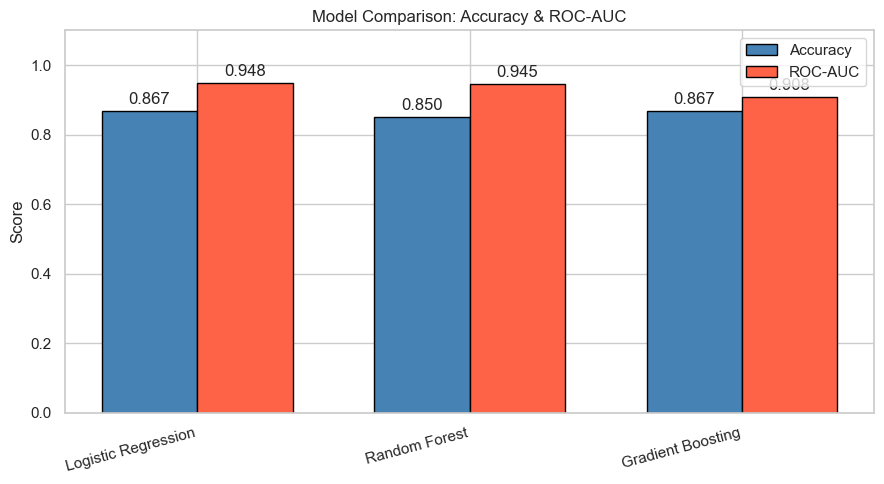

In [251]:
# Accuracy & AUC bar chart
names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
aucs  = [results[n]['auc'] for n in names]
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, aucs, width, label='ROC-AUC',  color='tomato',    edgecolor='black')
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

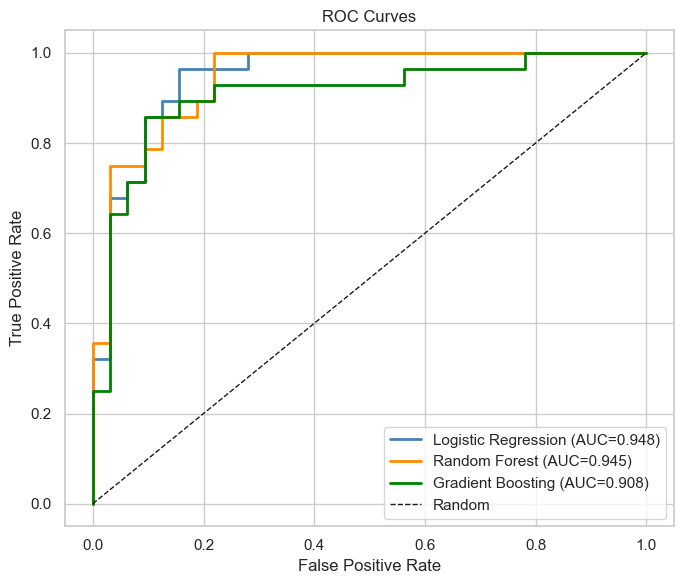

In [252]:
# Overlaid ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
for (name, res), color in zip(results.items(), ['steelblue', 'darkorange', 'green']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

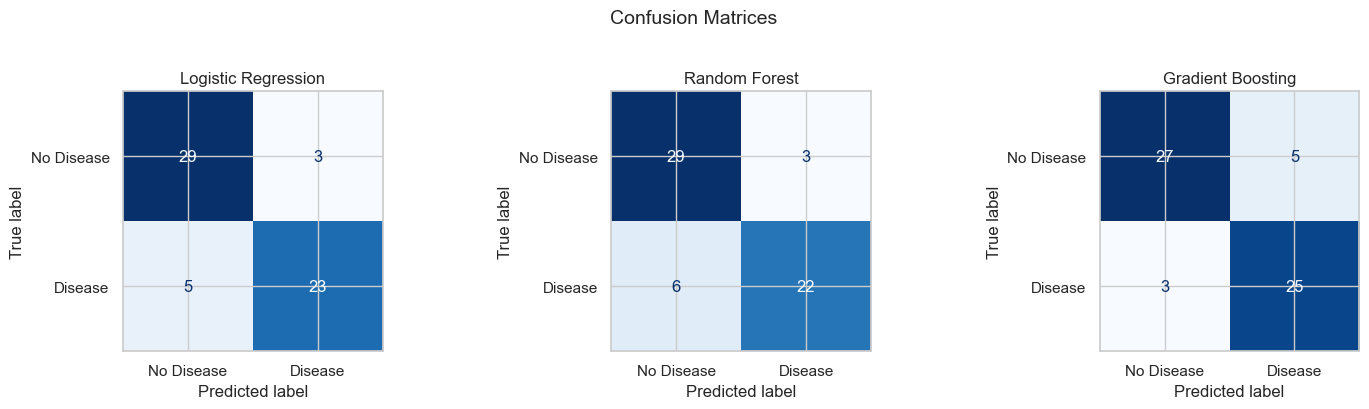

In [253]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [254]:
# Best model by ROC-AUC (for predictions and export)
best_name  = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_name]['model']
print(f'Best overall model: {best_name} (AUC={results[best_name]["auc"]:.4f})')

# SHAP model is always Random Forest â€” TreeExplainer does not support LogisticRegression
shap_name  = 'Random Forest'
shap_model = results[shap_name]['model']
print(f'SHAP model: {shap_name} (AUC={results[shap_name]["auc"]:.4f})')

Best overall model: Logistic Regression (AUC=0.9475)
SHAP model: Random Forest (AUC=0.9453)


## 7. SHAP Explainability

In [255]:
# Compute SHAP values using the best tree model
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# Normalize to 2D array for class 1 (disease)
# - Older SHAP: list of [class0_array, class1_array]
# - Newer SHAP: single 3D array (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    sv = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print(f'sv shape: {sv.shape}')  # should be (n_samples, n_features)

sv shape: (60, 21)


In [256]:
# Global SHAP summary: % contribution per feature
mean_abs_shap = np.abs(sv).mean(axis=0)
total         = mean_abs_shap.sum()
pct_shap      = mean_abs_shap / total * 100

shap_df = pd.DataFrame({
    'Feature': feature_cols,
    'Mean |SHAP|': mean_abs_shap,
    '% Contribution': pct_shap
})
shap_df = shap_df.sort_values('% Contribution', ascending=False).reset_index(drop=True)
print('Feature Risk Contributions (%):')
print(shap_df.to_string(index=False))

Feature Risk Contributions (%):
                      Feature  Mean |SHAP|  % Contribution
                           ca     0.076334       14.603800
                  thal_normal     0.072855       13.938104
       thal_reversable defect     0.065356       12.503478
                      oldpeak     0.051459        9.844813
                       thalch     0.037246        7.125742
                   exang_True     0.035161        6.726723
               cp_non-anginal     0.030973        5.925660
              slope_upsloping     0.026549        5.079234
                   slope_flat     0.023473        4.490627
                          age     0.021312        4.077241
                         chol     0.019545        3.739293
                     sex_Male     0.016682        3.191488
                     trestbps     0.011999        2.295573
               restecg_normal     0.010915        2.088144
           cp_atypical angina     0.009065        1.734169
            cp_typical a

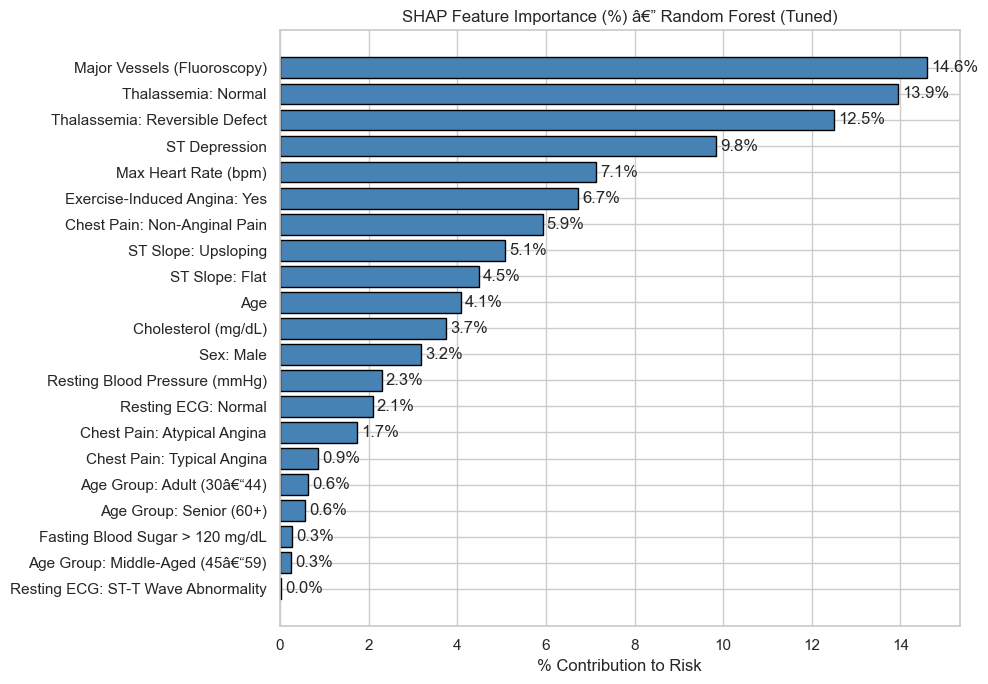

In [257]:
# Bar chart of % contribution â€” plain-speech labels
plain_labels = [FEATURE_LABEL_MAP.get(f, f) for f in feature_cols]
shap_df['Label'] = shap_df['Feature'].map(FEATURE_LABEL_MAP).fillna(shap_df['Feature'])

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(shap_df['Label'][::-1], shap_df['% Contribution'][::-1],
               color='steelblue', edgecolor='black')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('% Contribution to Risk')
ax.set_title(f'SHAP Feature Importance (%) â€” {shap_name} (Tuned)')
plt.tight_layout()
plt.show()

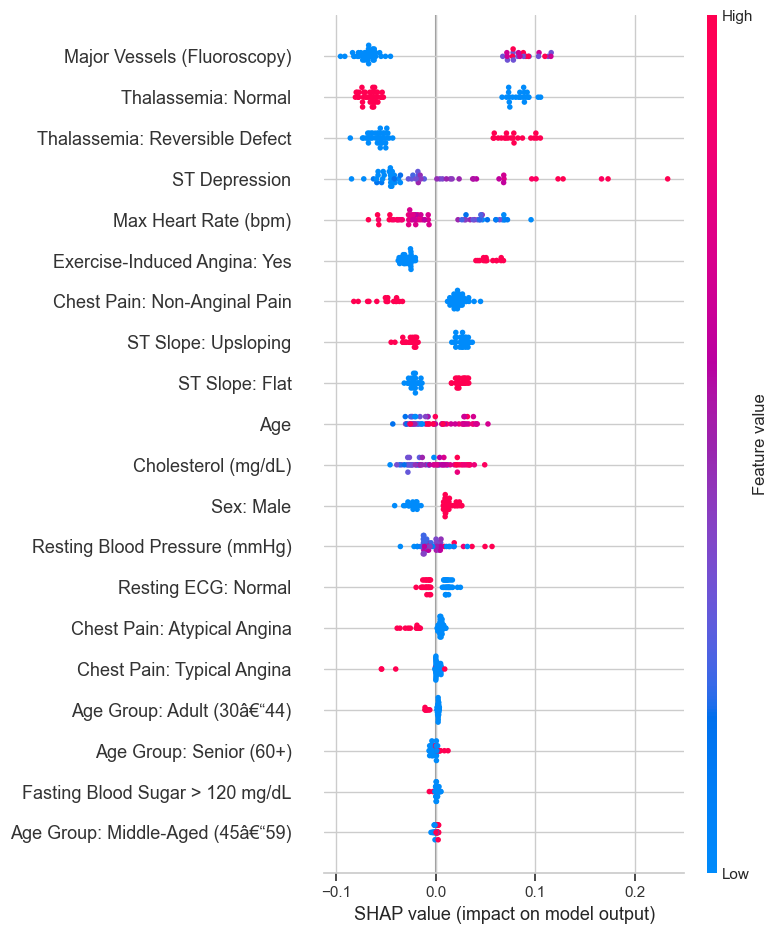

In [258]:
# Beeswarm plot: direction + magnitude â€” plain-speech labels
plain_labels = [FEATURE_LABEL_MAP.get(f, f) for f in feature_cols]
shap.summary_plot(sv, X_test, feature_names=plain_labels, show=True)

Explaining patient 18 (predicted risk: 99.2%)


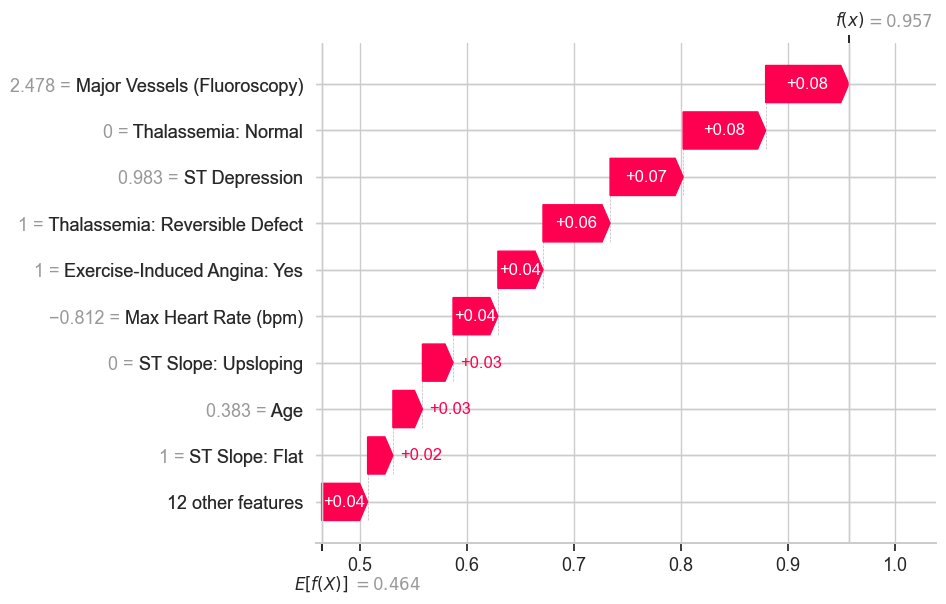

In [259]:
# Local waterfall: highest-risk test patient â€” plain-speech labels
plain_labels = [FEATURE_LABEL_MAP.get(f, f) for f in feature_cols]
highest_risk_idx = np.argmax(results[best_name]['y_proba'])
print(f'Explaining patient {highest_risk_idx} '
      f'(predicted risk: {results[best_name]["y_proba"][highest_risk_idx]:.1%})')

ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)) and np.ndim(ev) > 0:
    base_val = float(np.asarray(ev).flat[1] if len(np.asarray(ev)) > 1 else np.asarray(ev).flat[0])
else:
    base_val = float(ev)

shap.plots.waterfall(
    shap.Explanation(
        values=sv[highest_risk_idx],
        base_values=base_val,
        data=X_test.iloc[highest_risk_idx].values,
        feature_names=plain_labels
    )
)

## 8. Export Model for Dashboard

In [260]:
joblib.dump(best_model, 'model.pkl')
joblib.dump(shap_model, 'shap_model.pkl')
print(f'Saved {best_name} as model.pkl (predictions)')
print(f'Saved {shap_name} as shap_model.pkl (explainability)')
print('Dashboard artifacts ready: model.pkl, shap_model.pkl, scaler.pkl, feature_cols.pkl')

Saved Logistic Regression as model.pkl (predictions)
Saved Random Forest as shap_model.pkl (explainability)
Dashboard artifacts ready: model.pkl, shap_model.pkl, scaler.pkl, feature_cols.pkl
